# Signaux stochastiques — de R_xx à la méthode de Welch

**Contexte :** dans la vérification métrologique du SAVER 3X90, on génère un signal
vibratoire aléatoire conforme à la norme ASTM D4728 par **synthèse de Shinozuka**,
on l'injecte dans la chaîne d'acquisition simulée, et on restitue la DSP par la
**méthode de Welch**.

Cette fiche rappelle les notions nécessaires :

1. Signal déterministe vs stochastique
2. Stationnarité et caractérisation statistique : μ, σ², R_xx(τ), S_xx(f)
3. Distribution gaussienne et théorème central limite
4. Théorème de Wiener-Khintchine : S_xx ↔ R_xx
5. Ergodicité
6. Synthèse de Shinozuka (1972) et convergence gaussienne
7. Méthode de Welch et réduction de variance

In [2]:
import numpy as np
from scipy.signal import welch, correlate, correlation_lags
from scipy.stats import norm
import matplotlib.pyplot as plt

rng   = np.random.default_rng(42)
fe    = 1000     # Hz — frequence d'echantillonnage
T     = 30.0     # duree du signal (s)
N     = int(fe * T)
t     = np.arange(N) / fe
sigma = 0.40     # g_rms — valeur efficace cible (ordre de grandeur ASTM D4728)
x_sto = rng.normal(0, sigma, N)     # bruit blanc gaussien stationnaire
S0    = 2 * sigma**2 / fe           # DSP theorique (bruit blanc unilaterale)

## 1. Signal déterministe vs signal stochastique

Un signal **déterministe** est entièrement prévisible : sa valeur en tout instant futur
est calculable. Exemple : $x(t) = A\sin(2\pi ft + \varphi)$.

Un signal **stochastique** (ou aléatoire) ne peut pas être prédit exactement.
On le caractérise par ses **propriétés statistiques**.

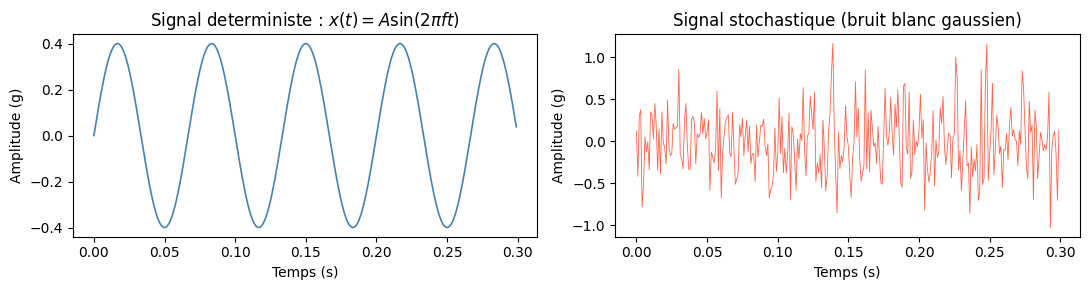

In [5]:
x_det = 0.4 * np.sin(2 * np.pi * 15 * t)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(t[:300], x_det[:300], lw=1.2, color='steelblue')
axes[0].set_title('Signal deterministe : $x(t) = A\\sin(2\\pi ft)$')
axes[0].set_xlabel('Temps (s)'); axes[0].set_ylabel('Amplitude (g)')

axes[1].plot(t[:300], x_sto[:300], lw=0.6, color='tomato')
axes[1].set_title('Signal stochastique (bruit blanc gaussien)')
axes[1].set_xlabel('Temps (s)'); axes[1].set_ylabel('Amplitude (g)')
plt.tight_layout(); plt.show()

## 2. Stationnarité et caractérisation statistique

Un processus stochastique est **stationnaire au sens large (WSS)** si :
- sa **moyenne** $\mu = \mathrm{E}[x(t)]$ est constante dans le temps ;
- sa **fonction d'autocorrélation** $R_{xx}(t_1, t_2) = \mathrm{E}[x(t_1)\cdot x(t_2)]$
  ne dépend que du décalage $\tau = t_2 - t_1$, pas des instants absolus.

Pour un processus stationnaire gaussien, la caractérisation complète est :

| Grandeur | Définition | Unité | Rôle |
|---|---|---|---|
| Moyenne | $\mu = \mathrm{E}[x(t)]$ | g | Composante DC (= 0 pour vibrations) |
| Variance | $\sigma^2 = \mathrm{E}[(x-\mu)^2]$ | g² | Puissance totale |
| Autocorrélation | $R_{xx}(\tau) = \mathrm{E}[x(t)\cdot x(t+\tau)]$ | g² | Mémoire temporelle |
| DSP | $S_{xx}(f) = \mathcal{F}\{R_{xx}(\tau)\}$ | g²/Hz | Répartition spectrale |

**Propriété clé :** $\sigma^2 = R_{xx}(0) = \displaystyle\int_{-\infty}^{+\infty} S_{xx}(f)\,df$

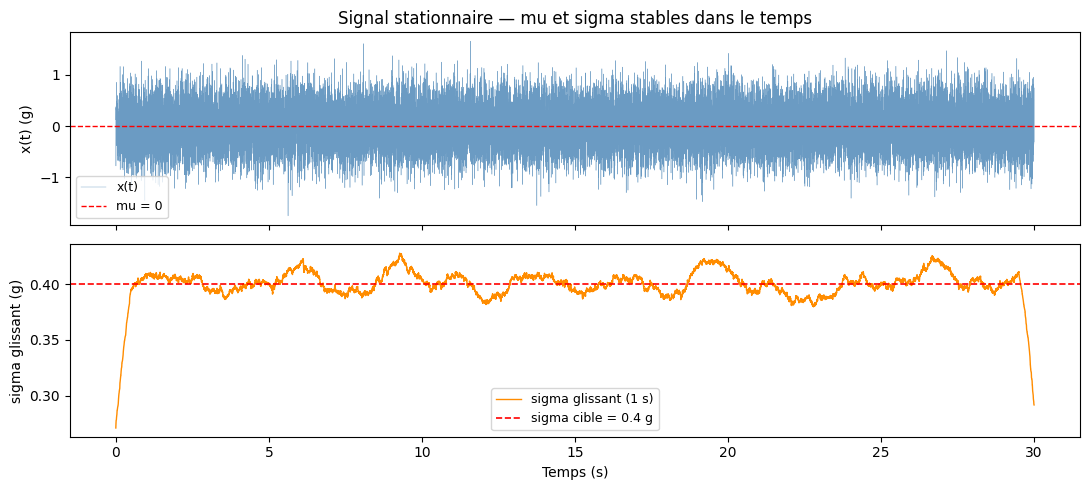

mu    = 0.0033 g   (attendu : 0)
sigma = 0.4017 g   (attendu : 0.4)


In [6]:
# Moyenne et ecart-type glissants (fenetre 1 s)
def rolling_stats(x, w):
    kernel = np.ones(w) / w
    mu_r   = np.convolve(x,    kernel, mode='same')
    var_r  = np.convolve(x**2, kernel, mode='same') - mu_r**2
    return mu_r, np.sqrt(np.clip(var_r, 0, None))

mu_r, std_r = rolling_stats(x_sto, fe)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, x_sto, lw=0.3, color='steelblue', alpha=0.8, label='x(t)')
axes[0].axhline(0, color='red', ls='--', lw=1, label='mu = 0')
axes[0].set_ylabel('x(t) (g)'); axes[0].legend(fontsize=9)
axes[0].set_title('Signal stationnaire — mu et sigma stables dans le temps')

axes[1].plot(t, std_r, lw=1, color='darkorange', label='sigma glissant (1 s)')
axes[1].axhline(sigma, color='red', ls='--', lw=1.2, label=f'sigma cible = {sigma} g')
axes[1].set_xlabel('Temps (s)'); axes[1].set_ylabel('sigma glissant (g)')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"mu    = {x_sto.mean():.4f} g   (attendu : 0)")
print(f"sigma = {x_sto.std():.4f} g   (attendu : {sigma})")

## 3. Distribution gaussienne et théorème central limite

Pour un processus **gaussien**, la distribution de $x(t)$ est une loi normale :

$$x(t) \sim \mathcal{N}(\mu,\, \sigma^2) \quad\Longrightarrow\quad p(x) = \frac{1}{\sigma\sqrt{2\pi}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Pour un processus gaussien stationnaire, $\mu$ et $\sigma^2$ (ou de façon équivalente $S_{xx}(f)$)
suffisent à **caractériser entièrement** le processus.

**Pourquoi les vibrations de transport sont gaussiennes ?**
Par le **théorème central limite (TCL)** : les vibrations sont la superposition de nombreuses
sources indépendantes (moteur, route, suspension, chargement...). Leur somme tend vers
une loi normale, quelle que soit la distribution de chaque source.

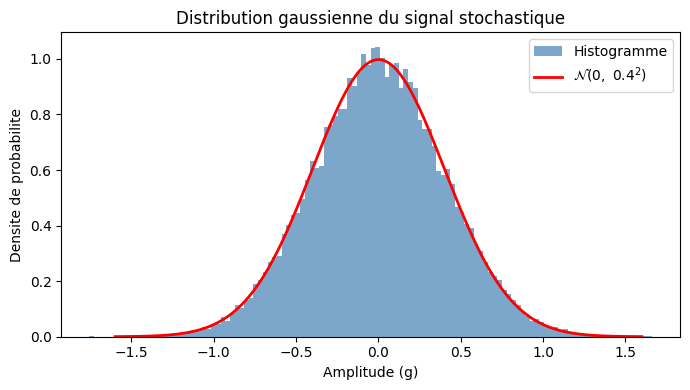

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x_sto, bins=120, density=True, color='steelblue', alpha=0.7, label='Histogramme')
x_fit = np.linspace(-4 * sigma, 4 * sigma, 400)
ax.plot(x_fit, norm.pdf(x_fit, 0, sigma), 'r-', lw=2,
        label=f'$\\mathcal{{N}}(0,\ {sigma}^2)$')
ax.set_xlabel('Amplitude (g)'); ax.set_ylabel('Densite de probabilite')
ax.set_title('Distribution gaussienne du signal stochastique')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Fonction d'autocorrélation R_xx(τ)

$$R_{xx}(\tau) = \mathrm{E}[x(t)\cdot x(t+\tau)]$$

Propriétés :
- $R_{xx}(0) = \sigma^2$ (puissance totale).
- $R_{xx}(\tau) \to 0$ quand $\tau \to \infty$ (le signal perd la mémoire de son passé).
- Symétrie : $R_{xx}(-\tau) = R_{xx}(\tau)$.
- **Bruit blanc :** $R_{xx}(\tau) = \sigma^2\,\delta(\tau)$ — décorrélation instantanée.

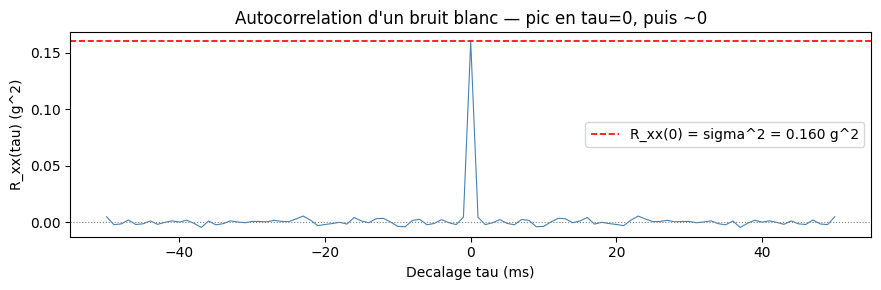

R_xx(0)  = 0.1599 g^2   (attendu : sigma^2 = 0.1600 g^2)


In [8]:
x_sub = x_sto[:5 * fe]   # 5 s suffit pour estimer R_xx
corr  = correlate(x_sub, x_sub, mode='full') / len(x_sub)
lags  = correlation_lags(len(x_sub), len(x_sub), mode='full') / fe
mask  = np.abs(lags) <= 0.05    # affichage sur +/- 50 ms

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(lags[mask] * 1e3, corr[mask], lw=0.8, color='steelblue')
ax.axhline(sigma**2, color='red', ls='--', lw=1.2,
           label=f'R_xx(0) = sigma^2 = {sigma**2:.3f} g^2')
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Decalage tau (ms)'); ax.set_ylabel('R_xx(tau) (g^2)')
ax.set_title("Autocorrelation d'un bruit blanc — pic en tau=0, puis ~0")
ax.legend(); plt.tight_layout(); plt.show()

idx0 = len(x_sub) - 1
print(f"R_xx(0)  = {corr[idx0]:.4f} g^2   (attendu : sigma^2 = {sigma**2:.4f} g^2)")

## 5. Théorème de Wiener-Khintchine : S_xx ↔ R_xx

La densité spectrale de puissance est la **transformée de Fourier** de la fonction
d'autocorrélation :

$$S_{xx}(f) = \int_{-\infty}^{+\infty} R_{xx}(\tau)\,e^{-j2\pi f\tau}\,d\tau
\quad\longleftrightarrow\quad
R_{xx}(\tau) = \int_{-\infty}^{+\infty} S_{xx}(f)\,e^{+j2\pi f\tau}\,df$$

Conséquences :
- $\sigma^2 = R_{xx}(0) = \displaystyle\int S_{xx}(f)\,df$ (l'intégrale de $S_{xx}$ donne la puissance).
- **Bruit blanc :** $R_{xx}(\tau) = \sigma^2\,\delta(\tau)$ $\Rightarrow$ $S_{xx}(f) = \text{const}$ (spectre plat).
- En pratique on estime $S_{xx}$ depuis un enregistrement via la méthode de Welch (section 7).

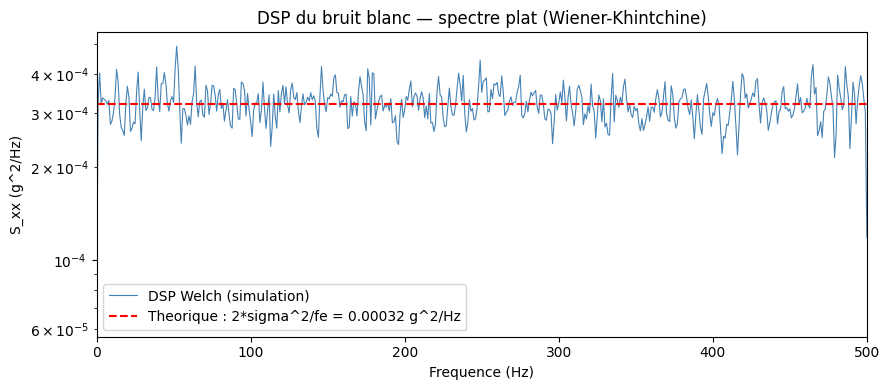

sigma depuis integrale(S_xx) = 0.4012 g   (attendu : 0.4000 g)


In [9]:
f_w, S_w = welch(x_sto, fs=fe, nperseg=fe, window='hann', scaling='density')

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(f_w, S_w, lw=0.8, color='steelblue', label='DSP Welch (simulation)')
ax.axhline(S0, color='red', ls='--', lw=1.5,
           label=f'Theorique : 2*sigma^2/fe = {S0:.5f} g^2/Hz')
ax.set_xlabel('Frequence (Hz)'); ax.set_ylabel('S_xx (g^2/Hz)')
ax.set_title('DSP du bruit blanc — spectre plat (Wiener-Khintchine)')
ax.set_xlim(0, fe / 2); ax.legend(); plt.tight_layout(); plt.show()

sigma_welch = np.sqrt(np.trapezoid(S_w, f_w))
print(f"sigma depuis integrale(S_xx) = {sigma_welch:.4f} g   (attendu : {sigma:.4f} g)")

## 6. Ergodicité

Un processus est **ergodique** si les **moyennes temporelles** (sur une seule longue réalisation)
égalent les **moyennes d'ensemble** (sur de nombreuses réalisations indépendantes).

$$\lim_{T\to\infty}\frac{1}{T}\int_0^T x(t)\,dt = \mathrm{E}[x(t)] = \mu$$

En pratique : une seule mesure longue est aussi informative que de nombreuses mesures courtes.
C'est l'hypothèse qui fonde la méthode de Welch : on estime $S_{xx}(f)$ depuis **un seul
enregistrement**. Sans ergodicité, il faudrait répéter l'expérience $K$ fois.

*Le signal de transport routier est supposé stationnaire et ergodique sur la durée d'un essai
(typiquement 3 h selon ASTM D4728).*

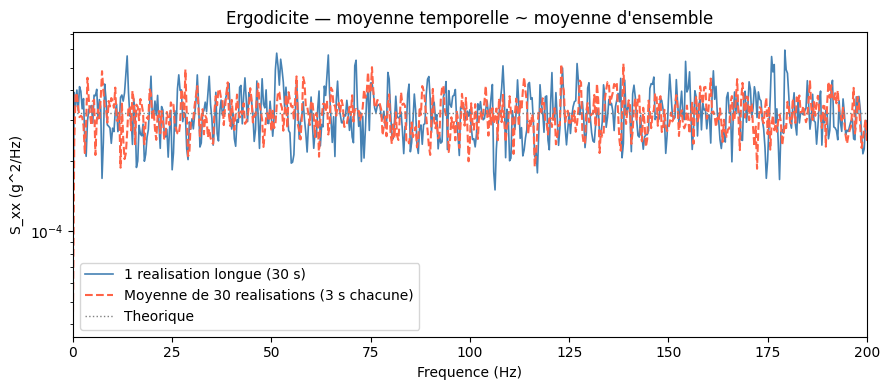

In [10]:
K_erg  = 30
T_ct   = 3.0
N_ct   = int(fe * T_ct)

S_ens_sum = np.zeros(N_ct // 2 + 1)
for _ in range(K_erg):
    x_k     = rng.normal(0, sigma, N_ct)
    f_k, Sk = welch(x_k, fs=fe, nperseg=N_ct, window='hann', scaling='density')
    S_ens_sum += Sk
S_ens = S_ens_sum / K_erg

f_long, S_long = welch(x_sto, fs=fe, nperseg=N_ct, window='hann', scaling='density')

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(f_long, S_long, lw=1.2, color='steelblue',
            label=f'1 realisation longue ({T:.0f} s)')
ax.semilogy(f_k, S_ens, lw=1.5, color='tomato', ls='--',
            label=f'Moyenne de {K_erg} realisations ({T_ct:.0f} s chacune)')
ax.axhline(S0, color='gray', ls=':', lw=1, label='Theorique')
ax.set_xlabel('Frequence (Hz)'); ax.set_ylabel('S_xx (g^2/Hz)')
ax.set_title("Ergodicite — moyenne temporelle ~ moyenne d'ensemble")
ax.set_xlim(0, 200); ax.legend(); plt.tight_layout(); plt.show()

## 7. Synthèse de Shinozuka (1972)

Pour générer un signal aléatoire dont la DSP cible est $S_{\text{cible}}(f)$, on construit :

$$x(t) = \sum_{k=1}^{N} \underbrace{\sqrt{2\,S_{\text{cible}}(f_k)\,\Delta f}}_{A_k}\;\cos(2\pi f_k t + \varphi_k)$$

avec $\varphi_k \sim \mathcal{U}[0,\,2\pi]$ indépendants, $f_k = f_1 + k\,\Delta f$.

**Propriétés :**
- $\mathrm{E}[x(t)] = 0$ (les cosinus à phases aléatoires ont une espérance nulle).
- La DSP de $x(t)$ converge vers $S_{\text{cible}}(f)$ quand $N \to \infty$.
- **TCL :** la somme de $N$ cosinus à phases i.i.d. tend vers $\mathcal{N}(0, \sigma^2)$.
  Pour $N \gtrsim 50$ composantes, $x(t)$ est pratiquement gaussien.

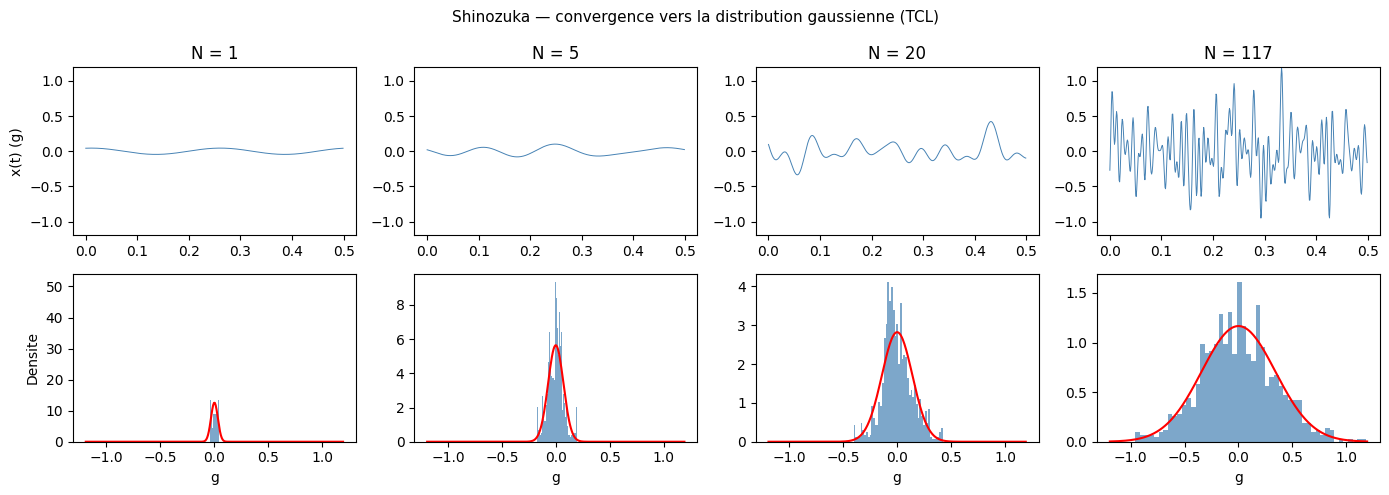

DSP moyenne [4–120 Hz] : 0.00103 g^2/Hz   (cible : 0.00100)
sigma restitue            : 0.3464 g   (cible : 0.3406 g)


In [11]:
# Cible : DSP plate S_cible sur [f1, f2]
f1, f2   = 4.0, 120.0
df_sh    = 1.0
S_cible  = 0.001                              # g^2/Hz (illustratif)
sigma_sh = np.sqrt(S_cible * (f2 - f1))       # g_rms theorique
freqs_sh = np.arange(f1, f2 + df_sh, df_sh)
Ak       = np.sqrt(2 * S_cible * df_sh)       # amplitudes uniformes (DSP plate)

t_sh   = np.linspace(0, 10, 10001)
N_vals = [1, 5, 20, len(freqs_sh)]
x_fit_g = np.linspace(-3.5 * sigma_sh, 3.5 * sigma_sh, 300)

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for col, Nk in enumerate(N_vals):
    rng_i = np.random.default_rng(10 + col)
    phi_k = rng_i.uniform(0, 2 * np.pi, Nk)
    fk    = freqs_sh[:Nk]
    x_sh  = (Ak * np.cos(2 * np.pi * fk[:, None] * t_sh[None, :]
              + phi_k[:, None])).sum(axis=0)

    axes[0, col].plot(t_sh[:500], x_sh[:500], lw=0.7, color='steelblue')
    axes[0, col].set_title(f'N = {Nk}')
    axes[0, col].set_ylim(-3.5 * sigma_sh, 3.5 * sigma_sh)
    if col == 0: axes[0, col].set_ylabel('x(t) (g)')

    s_eff = x_sh.std()
    axes[1, col].hist(x_sh, bins=50, density=True, color='steelblue', alpha=0.7)
    axes[1, col].plot(x_fit_g, norm.pdf(x_fit_g, 0, max(s_eff, 1e-9)), 'r-', lw=1.5)
    axes[1, col].set_xlabel('g')
    if col == 0: axes[1, col].set_ylabel('Densite')

fig.suptitle('Shinozuka — convergence vers la distribution gaussienne (TCL)', fontsize=11)
plt.tight_layout(); plt.show()

# Verification : DSP du signal Shinozuka complet
rng_v   = np.random.default_rng(99)
phi_all = rng_v.uniform(0, 2 * np.pi, len(freqs_sh))
t_v     = np.arange(30 * fe) / fe
x_v     = (Ak * np.cos(2 * np.pi * freqs_sh[:, None] * t_v[None, :]
            + phi_all[:, None])).sum(axis=0)
f_v, S_v = welch(x_v, fs=fe, nperseg=fe, window='hann', scaling='density')
mask_v   = (f_v >= f1) & (f_v <= f2)
print(f"DSP moyenne [{f1:.0f}–{f2:.0f} Hz] : {S_v[mask_v].mean():.5f} g^2/Hz   (cible : {S_cible:.5f})")
print(f"sigma restitue            : {np.sqrt(np.trapezoid(S_v[mask_v], f_v[mask_v])):.4f} g   (cible : {sigma_sh:.4f} g)")

## 8. Méthode de Welch — réduction de variance

Le **périodogramme** (FFT directe du signal entier) est un estimateur **non biaisé** de $S_{xx}$
mais à **variance élevée** : il ne converge pas avec la durée du signal.

La méthode de **Welch** découpe le signal en $K$ fenêtres pondérées de longueur $N_{\text{fen}}$,
calcule le périodogramme de chacune, puis moyenne :

$$\hat{S}_{xx}(f) = \frac{1}{K}\sum_{i=1}^{K}\left|X_i(f)\right|^2$$

**Compromis résolution / variance :**
- Variance $\propto 1/K$ : $K$ grand → estimateur plus lisse.
- Résolution fréquentielle $\Delta f = f_e / N_{\text{fen}}$ : $K$ grand → $\Delta f$ plus grossier.

*C'est la méthode utilisée par le SAVER 3X90 pour restituer la DSP de transport.*

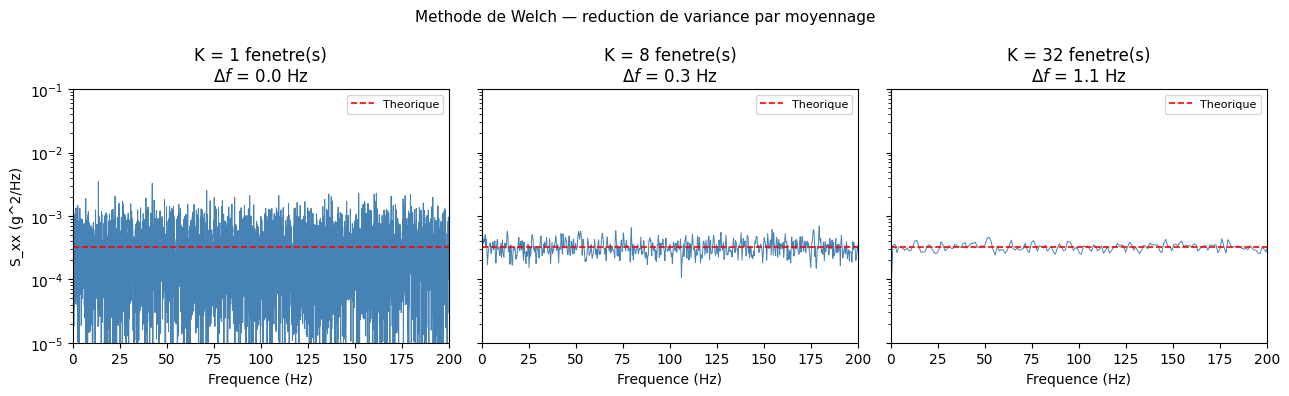

In [12]:
K_vals = [1, 8, 32]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, K_w in zip(axes, K_vals):
    nperseg_w  = max(N // K_w, 32)
    f_ww, S_ww = welch(x_sto, fs=fe, nperseg=nperseg_w, window='hann', scaling='density')
    ax.semilogy(f_ww, S_ww, lw=0.7, color='steelblue')
    ax.axhline(S0, color='red', ls='--', lw=1.2, label='Theorique')
    ax.set_title(f'K = {K_w} fenetre(s)\n$\\Delta f$ = {fe/nperseg_w:.1f} Hz')
    ax.set_xlabel('Frequence (Hz)')
    ax.set_xlim(0, 200); ax.set_ylim(1e-5, 1e-1)
    ax.legend(fontsize=8)

axes[0].set_ylabel('S_xx (g^2/Hz)')
fig.suptitle('Methode de Welch — reduction de variance par moyennage', fontsize=11)
plt.tight_layout(); plt.show()

## Synthèse

| Grandeur | Symbole | Unité | Rôle dans la vérification |
|---|---|---|---|
| Moyenne | μ | g | Nulle pour vibrations |
| Variance / puissance | σ² = R_xx(0) = ∫S_xx df | g² | Puissance totale |
| Ecart-type | σ | g_rms | Valeur efficace |
| Autocorrélation | R_xx(τ) | g² | Mémoire temporelle |
| DSP | S_xx(f) = TF{R_xx} | g²/Hz | Répartition spectrale — grandeur cible |
| Loi gaussienne | x ~ N(0, σ²) | — | TCL + Shinozuka → μ et S_xx suffisent |

**Hypothèses de la vérification SAVER 3X90 :**
1. Signal d'entrée : gaussien, stationnaire, ergodique (conforme ASTM D4728).
2. Génération : méthode de Shinozuka → DSP cible reproduite en moyenne.
3. Restitution : méthode de Welch → estimateur à variance réduite.
4. Critère d'acceptation : écart DSP restituée / DSP cible dans une tolérance fixée.